In [ ]:
# We Incorporate Long Term Memory with SQLSaver
# Inmemorysaver() is limited to session

from langgraph.graph import MessagesState
class MessagesState(MessagesState):
  pass

In [ ]:

pip install -U langchain-google-genai

In [ ]:
## For chat bot we need Interactive Message so first wen need LLM
import os
from google.colab import userdata
os.environ['GOOGLE_API_KEY']=userdata.get('GEMINI4')

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash")

In [ ]:
pip install -U duckduckgo-search langchain-community


In [ ]:
pip install -U ddgs

In [ ]:
# importing the tool Information
from langchain_core.tools import tool
from langgraph.prebuilt import tool_node, tools_condition


In [ ]:
from langchain_community.tools import DuckDuckGoSearchResults
search = DuckDuckGoSearchResults()

In [ ]:
# importing DUCk DUCK Search toola
@tool
def SearchEngine(query: str):
  ''' Like you afre the tool defined by the user so main thing is LLM is unaware about recent info,
  so Provide the updated information, gto model'''
  return search.run(query)

In [ ]:
# Lets define Tools Node

tools=tool_node.ToolNode(
    tools=[SearchEngine]
)

In [ ]:
# let our LLM know these tools
Lmm_with_tools=llm.bind(tools=[SearchEngine])

In [ ]:
# Creating the Chat BOT NODES
def ChatNode(state :MessagesState ):
  response=Lmm_with_tools.invoke(state['messages'])
  return {'messages':[response] }

In [ ]:
# Creating graph

from langgraph.graph import StateGraph, START, END


In [ ]:
graph_var=StateGraph(MessagesState)

In [ ]:
graph_var.add_node('ChatNode', ChatNode)
graph_var.add_node('tools',tools)

In [ ]:
graph_var.add_edge(START, 'ChatNode')
graph_var.add_conditional_edges('ChatNode', tools_condition, {'tools':'tools' , END:END})
graph_var.add_edge( 'tools', 'ChatNode')

In [ ]:
pip install -U langgraph-checkpoint-sqlite

In [ ]:
# Now add the Memory]
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver


In [ ]:
checkpointer=sqlite3.connect('Mymemory.db', check_same_thread=False) # SO we can generate responses with diffrent threads
Memory=SqliteSaver(checkpointer)

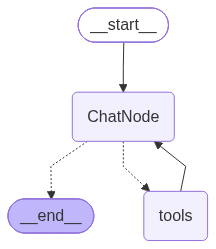

In [ ]:
graph=graph_var.compile(checkpointer=Memory)
graph

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage

In [ ]:
system_prompt="""
Hey LLM Iknow you are an expert, but many llms are unaware about the most recent news or affairs to take help of given tool and produce the answer,
 if you were aware of content just give answer in single word  with small description
Answer the user query acc to latest information provided by tool if you unaware
  if User ask who won IPL & tool gave BIG para sentence , consize it  : You should Answer like  : RCB  [a Bengaluru TEAM, Got troffy at NAMO stadium IPL 2026],
  if User ASK about india PM & tool gave BIG para sentence , consize it   :You should Answer : Narendra MODI [Member of parlament], Leader of ruling party, BJP
  Like wise Any today UPDATES or recent updates you answer in single word with small description
  """

In [ ]:
res=graph.invoke({'messages':[SystemMessage(content=system_prompt),
                          HumanMessage(content='Any central miniter from delhi resigned yesterday? ')]},
                {'configurable': {'thread_id': 'political'}}
                           )
for every in res['messages']:
  every.pretty_print()

In [ ]:
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================

 I believe you are unaware about recent updates , So use the tool i provided, Give  consized Output in simple words 
================================ Human Message =================================

what is today news delhi, any political resignations 
================================== Ai Message ==================================
Tool Calls:
  SearchEngine (a387833e-d851-445a-8970-6519a3e98cae)
 Call ID: a387833e-d851-445a-8970-6519a3e98cae
  Args:
    query: today's news Delhi political resignations
================================= Tool Message =================================
Name: SearchEngine

snippet: Check out the latest news from India and around the world. Latest India news on Bollywood, Politics, Business, Cricket, Technology and Travel., title: Latest News, Breaking News Today - Entertainment... - India Today, link: https://www.indiatoday.in/, snippet: Today's top India news headlines, news 

In [ ]:
def INVOKE(Query: str):
  res=graph.invoke({'messages':[SystemMessage(content=system_prompt),
                          HumanMessage(content=Query)]},
                {'configurable': {'thread_id': 'political'}}
                           )
  return res

In [ ]:
res=INVOKE("My name is chidvilas")
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================

 I believe you are unaware about recent updates , So use the tool i provided, Give  consized Output in simple words 
================================ Human Message =================================

what is today news delhi, any political resignations 
================================== Ai Message ==================================
Tool Calls:
  SearchEngine (a387833e-d851-445a-8970-6519a3e98cae)
 Call ID: a387833e-d851-445a-8970-6519a3e98cae
  Args:
    query: today's news Delhi political resignations
================================= Tool Message =================================
Name: SearchEngine

snippet: Check out the latest news from India and around the world. Latest India news on Bollywood, Politics, Business, Cricket, Technology and Travel., title: Latest News, Breaking News Today - Entertainment... - India Today, link: https://www.indiatoday.in/, snippet: Today's top India news headlines, news 

In [ ]:
res=INVOKE("DEFINE LOVE")
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================

 I believe you are unaware about recent updates , So use the tool i provided, Give  consized Output in simple words 
================================ Human Message =================================

what is today news delhi, any political resignations 
================================== Ai Message ==================================
Tool Calls:
  SearchEngine (a387833e-d851-445a-8970-6519a3e98cae)
 Call ID: a387833e-d851-445a-8970-6519a3e98cae
  Args:
    query: today's news Delhi political resignations
================================= Tool Message =================================
Name: SearchEngine

snippet: Check out the latest news from India and around the world. Latest India news on Bollywood, Politics, Business, Cricket, Technology and Travel., title: Latest News, Breaking News Today - Entertainment... - India Today, link: https://www.indiatoday.in/, snippet: Today's top India news headlines, news 

In [ ]:
res=INVOKE("what is my name")
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================

 I believe you are unaware about recent updates , So use the tool i provided, Give  consized Output in simple words 
================================ Human Message =================================

what is today news delhi, any political resignations 
================================== Ai Message ==================================
Tool Calls:
  SearchEngine (a387833e-d851-445a-8970-6519a3e98cae)
 Call ID: a387833e-d851-445a-8970-6519a3e98cae
  Args:
    query: today's news Delhi political resignations
================================= Tool Message =================================
Name: SearchEngine

snippet: Check out the latest news from India and around the world. Latest India news on Bollywood, Politics, Business, Cricket, Technology and Travel., title: Latest News, Breaking News Today - Entertainment... - India Today, link: https://www.indiatoday.in/, snippet: Today's top India news headlines, news 

## Restarting the Session now
- So My details stored in DataBase
- It was Giving my credentials correctly even after restarting session after long time

#### We got it

In [ ]:
res=INVOKE("what is my name")
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================

 I believe you are unaware about recent updates , So use the tool i provided, Give  consized Output in simple words 
================================ Human Message =================================

what is today news delhi, any political resignations 
================================== Ai Message ==================================
Tool Calls:
  SearchEngine (a387833e-d851-445a-8970-6519a3e98cae)
 Call ID: a387833e-d851-445a-8970-6519a3e98cae
  Args:
    query: today's news Delhi political resignations
================================= Tool Message =================================
Name: SearchEngine

snippet: Check out the latest news from India and around the world. Latest India news on Bollywood, Politics, Business, Cricket, Technology and Travel., title: Latest News, Breaking News Today - Entertainment... - India Today, link: https://www.indiatoday.in/, snippet: Today's top India news headlines, news 